# 🫘 Notebook 05 – Tiền xử lý & Huấn luyện: BỆNH THẬN (KIDNEY DISEASE)
**Dataset:** `kidney_disease.csv` (400 mẫu, 26 cột, 1009 missing values)  
**Sinh viên:** Lê Trung Hiếu – 102220187

---
### ⚠️ THÁCH THỨC: Dataset TẬT NHẤT (rất nhỏ, rất thưa thớt)
| Thách thức | Chi tiết |
|-----------|---------|
| **Size** | Chỉ 400 mẫu (vs 5K+ stroke, 100K diabetes) |
| **Missing** | 1,009 values missing (25% dữ liệu bị thiếu!) |
| **Features** | 26 cột, nhiều có <30% dữ liệu hợp lệ |
| **Phương pháp** | Chỉ dùng features >70% hợp lệ, imputation tích cực |

---

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 📦 PHẦN 0: IMPORT & LOAD

In [2]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns, matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve)
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import shap, joblib, os

# ==============================================================
# ✅ KHAI BÁO ĐƯỜNG DẪN ROOT ĐẾN GOOGLE DRIVE
# ==============================================================
DRIVE_PATH = '/content/drive/MyDrive/DATN_HealthRisk'
DIR_DATA = f'{DRIVE_PATH}/data'
DIR_MODELS = f'{DRIVE_PATH}/models'
DIR_RESULTS = f'{DRIVE_PATH}/results'

for d in [DIR_DATA, DIR_MODELS, DIR_RESULTS]:
    os.makedirs(d, exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid'); sns.set_palette("husl")
print("✅ Import thành công và đã trỏ đường dẫn gốc vào Google Drive!")

df_raw = pd.read_csv(f'{DIR_DATA}/kidney_disease.csv')
print("\n" + "=" * 70)
print("📊 KIDNEY DISEASE DATASET – 400 bệnh nhân (ĐẶC BIỆT THƯA THỚT)")
print("=" * 70)
print(f"Shape: {df_raw.shape}")
print(f"Missing total: {df_raw.isnull().sum().sum():,} ({df_raw.isnull().sum().sum()/(df_raw.shape[0]*df_raw.shape[1])*100:.1f}%)")
display(df_raw.head(2))

✅ Import thành công và đã trỏ đường dẫn gốc vào Google Drive!

📊 KIDNEY DISEASE DATASET – 400 bệnh nhân (ĐẶC BIỆT THƯA THỚT)
Shape: (400, 26)
Missing total: 1,009 (9.7%)


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.02,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.02,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd


---
## 📋 PHẦN 1.5: EDA – Phân phối chỉ số


📊 PHÂN PHỐI DỮ LIỆU (valid features only):


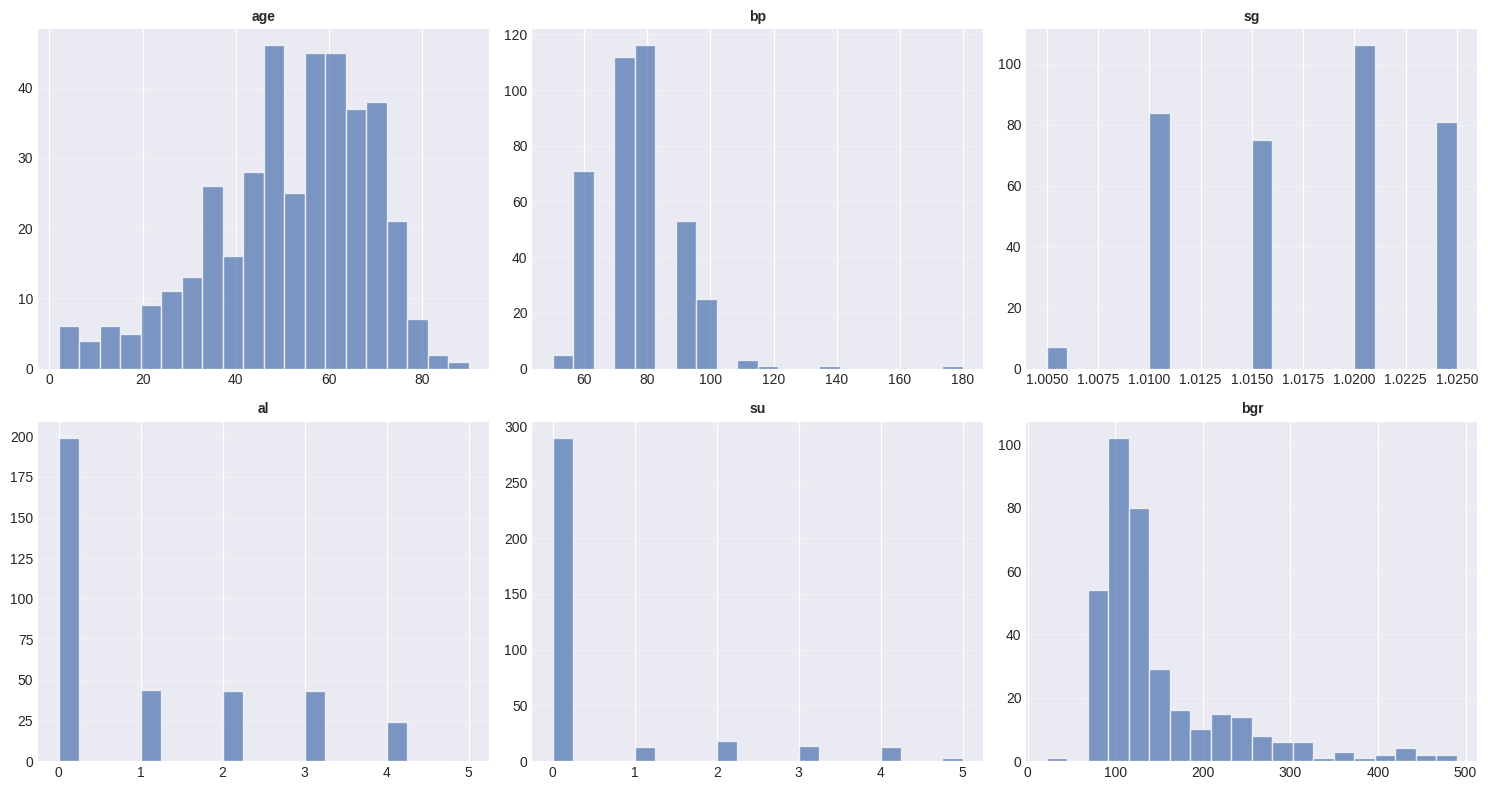

✅ EDA distributions saved


In [3]:
# Drop ID column first
df_raw_clean = df_raw.drop(columns=['id']).copy()

# For EDA, show valid numeric and categorical features
valid_numeric = df_raw_clean.select_dtypes('number').columns
valid_cat = df_raw_clean.select_dtypes('object').columns

print(f"📊 PHÂN PHỐI DỮ LIỆU (valid features only):")
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

numeric_to_plot = [c for c in valid_numeric if c != 'class'][:6]
for idx, col in enumerate(numeric_to_plot):
    ax = axes[idx]
    valid_data = df_raw_clean[col].dropna()
    if len(valid_data) > 0:
        ax.hist(valid_data, bins=20, alpha=0.7, color='#4C72B0', edgecolor='white')
        ax.set_title(col, fontsize=10, weight='bold')
        ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DIR_RESULTS}/K01_eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA distributions saved")


### 1.6 Correlation analysis (for valid features)


📊 CHUẨN BỊ DỮ LIỆU ĐỂ VẼ MA TRẬN TƯƠNG QUAN


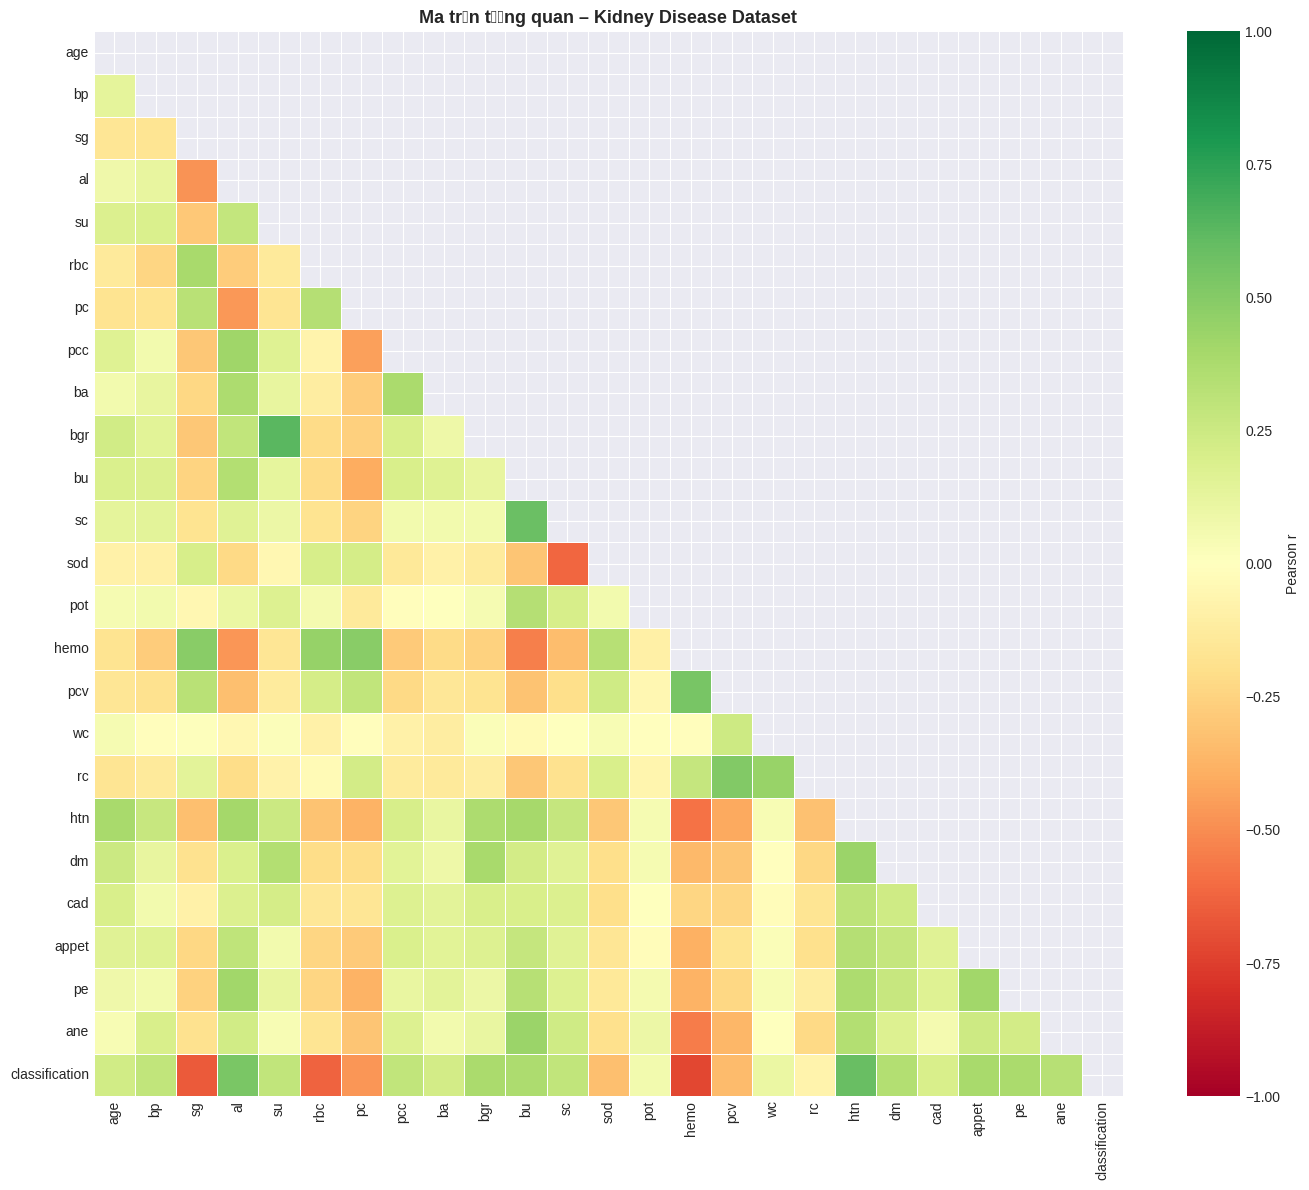


🔑 TOP CÁC CHỈ SỐ TƯƠNG QUAN MẠNH NHẤT VỚI BỆNH THẬN (classification):
  hemo            |█████████████████████         | 0.726
  sg              |███████████████████           | 0.660
  rbc             |██████████████████            | 0.626
  htn             |█████████████████             | 0.593
  al              |███████████████               | 0.532
  pc              |██████████████                | 0.472
  appet           |███████████                   | 0.389
  bgr             |███████████                   | 0.379
  pe              |███████████                   | 0.379
  bu              |███████████                   | 0.369


In [4]:
from sklearn.preprocessing import LabelEncoder

print("📊 CHUẨN BỊ DỮ LIỆU ĐỂ VẼ MA TRẬN TƯƠNG QUAN")
df_corr = df_raw_clean.copy()

# 1. Chỉ tính Median cho các cột dạng Số (Thêm tham số numeric_only=True)
df_corr.fillna(df_corr.median(numeric_only=True), inplace=True)

# 2. Xử lý cột nhãn Target (Sửa tên cột thành classification cho đúng dataset)
df_corr['classification'] = df_corr['classification'].astype(str).str.lower().str.strip()
df_corr['classification'] = df_corr['classification'].map({'ckd': 1, 'notckd': 0, 'ckd\t': 1})

# 3. Mã hóa (Label Encode) các cột dạng Chữ sang Số để tính tương quan
for col in df_corr.select_dtypes(include=['object']).columns:
    # Biến NaN thành chuỗi 'nan' rồi mã hóa luôn để không bị lỗi
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col].astype(str))

# ==========================================
# VẼ MA TRẬN TƯƠNG QUAN
# ==========================================
plt.figure(figsize=(14, 12))
corr_full = df_corr.corr()

# Tạo mask để che nửa trên của ma trận cho dễ nhìn
mask = np.triu(np.ones_like(corr_full, dtype=bool))

sns.heatmap(corr_full, mask=mask, annot=False, cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            cbar_kws={'label': 'Pearson r'})

plt.title('Ma trận tương quan – Kidney Disease Dataset', fontsize=13, weight='bold')
plt.tight_layout()
# Lưu biểu đồ vào Google Drive
plt.savefig(f'{DIR_RESULTS}/K02_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🔑 TOP CÁC CHỈ SỐ TƯƠNG QUAN MẠNH NHẤT VỚI BỆNH THẬN (classification):")
# Tính trị tuyệt đối để lấy những biến có sức ảnh hưởng mạnh nhất (dù âm hay dương)
corr_target = corr_full['classification'].drop('classification').abs().sort_values(ascending=False)
for feat, val in corr_target.head(10).items():
    bar = '█' * int(val * 30)
    print(f"  {feat:15s} |{bar:<30}| {val:.3f}")

---
## ⚙️ PHẦN 1: TIỀN XỬ LÝ (CẤP TIẾN)

In [5]:
df = df_raw.drop(columns=['id']).copy()
print("🔍 TIỀN XỬ LÝ KIDNEY (CẤP TIẾN – Dataset rất nhỏ & thưa)")
print("=" * 70)

# --- CLEAN: some clinical columns are strings and contain non-numeric chars ---
for col in ['pcv', 'wc', 'rc']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(r'[^0-9\.-]', '', regex=True), errors='coerce')

# Clean 'dm' which sometimes contains whitespace or tabs
if 'dm' in df.columns:
    df['dm'] = df['dm'].astype(str).str.replace('\t', '').str.strip().str.lower()
    df['dm'] = df['dm'].replace({'yes': 1, 'no': 0, 'nan': np.nan, '?': np.nan})

# 1. Feature selection: keep ≥70% valid data BUT force-keep clinically important cols
print("1️⃣  Feature selection (keep ≥70% valid data; force-keep pcv/wc/rc if present):")
valid_pct_threshold = 0.7
forced_keep = [c for c in ['rc', 'pcv', 'wc'] if c in df.columns]
valid_cols = []
for col in df.columns:
    valid_pct = (1 - df[col].isnull().sum() / len(df))
    if valid_pct >= valid_pct_threshold or col in forced_keep or col == 'classification':
        valid_cols.append(col)
        print(f"   ✅ {col:15s}: {valid_pct*100:5.1f}% valid")
    else:
        print(f"   ❌ {col:15s}: {valid_pct*100:5.1f}% valid → DROP")

df = df[valid_cols]
print(f"\n   Columns: {len(df_raw.columns)-1} → {len(df)} (removed sparse features)")

# 2. Encode classification column (class)
print(f"\n2️⃣  Target encoding:")
df['classification'] = df['classification'].astype(str).str.lower().str.strip()
class_map = {'ckd': 1, 'notckd': 0, 'ckd\t': 1}
df['classification'] = df['classification'].map(class_map)
target_col = 'classification'
print(f"   classification: ckd→1, notckd→0")
print(f"   Distribution: {df['classification'].value_counts().to_dict()}")

# 3. Encode categorical columns (LabelEncode small dataset) but skip already numeric cols
print(f"\n3️⃣  Categorical encoding (LabelEncoder for object cols):")
for col in df.select_dtypes(include=['object']).columns:
    if col != target_col:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        print(f"   ✅ {col}: encoded")

# 4. Impute numeric columns with median (aggressive imputation for small dataset)
print(f"\n4️⃣  Imputation (median for numeric):")
imputer = SimpleImputer(strategy='median')
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])
print(f"   All numeric columns → median imputation")

FEATURE_NAMES = [c for c in df.columns if c != target_col]
X, y = df.drop(columns=[target_col]), df[target_col]

print(f"\n  Final shape: {df.shape}")
print(f"  Null values: {df.isnull().sum().sum()}")
print(f"  {len(FEATURE_NAMES)} features: {FEATURE_NAMES}")

🔍 TIỀN XỬ LÝ KIDNEY (CẤP TIẾN – Dataset rất nhỏ & thưa)
1️⃣  Feature selection (keep ≥70% valid data; force-keep pcv/wc/rc if present):
   ✅ age            :  97.8% valid
   ✅ bp             :  97.0% valid
   ✅ sg             :  88.2% valid
   ✅ al             :  88.5% valid
   ✅ su             :  87.8% valid
   ❌ rbc            :  62.0% valid → DROP
   ✅ pc             :  83.8% valid
   ✅ pcc            :  99.0% valid
   ✅ ba             :  99.0% valid
   ✅ bgr            :  89.0% valid
   ✅ bu             :  95.2% valid
   ✅ sc             :  95.8% valid
   ✅ sod            :  78.2% valid
   ✅ pot            :  78.0% valid
   ✅ hemo           :  87.0% valid
   ✅ pcv            :  82.2% valid
   ✅ wc             :  73.5% valid
   ✅ rc             :  67.2% valid
   ✅ htn            :  99.5% valid
   ✅ dm             :  99.5% valid
   ✅ cad            :  99.5% valid
   ✅ appet          :  99.8% valid
   ✅ pe             :  99.8% valid
   ✅ ane            :  99.8% valid
   ✅ classificati

---
## 🔀 PHẦN 2: SPLIT → SMOTE → SCALE

🔀 SPLIT/SMOTE/SCALE:
  Train: 320 | Test: 80
  Train class: {0.0: np.int64(120), 1.0: np.int64(200)}
  Sau SMOTE: 400 | {0.0: np.int64(200), 1.0: np.int64(200)}
  💾 Lưu: kidney_scaler.pkl | features.pkl | test_raw.pkl


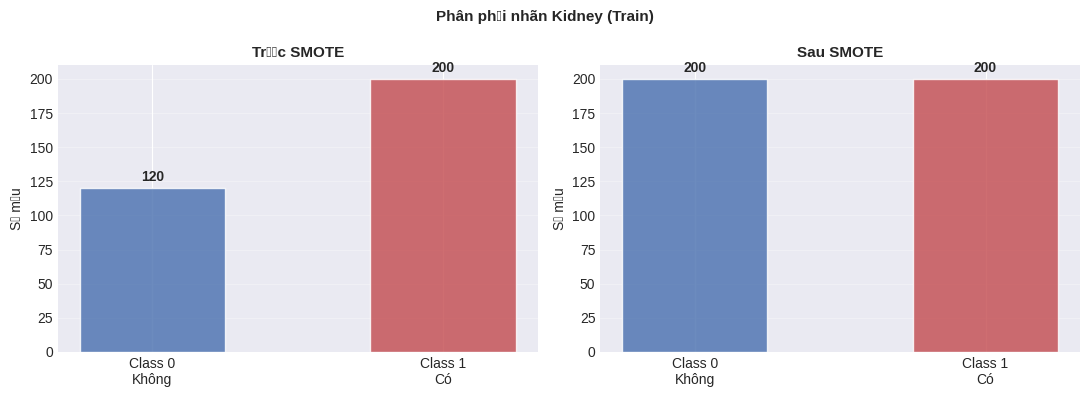

In [6]:
# 1. Split
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print("🔀 SPLIT/SMOTE/SCALE:")
print(f"  Train: {X_train_raw.shape[0]} | Test: {X_test_raw.shape[0]}")
print(f"  Train class: {dict(y_train_raw.value_counts().sort_index())}")

# 2. SMOTE (k_neighbors=3 vì dataset siêu nhỏ)
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_res, y_train_res = smote.fit_resample(X_train_raw, y_train_raw)
print(f"  Sau SMOTE: {X_train_res.shape[0]} | {dict(pd.Series(y_train_res).value_counts().sort_index())}")

# 3. Scale
scaler = StandardScaler()
X_train_d = scaler.fit_transform(X_train_res)
X_test_d  = scaler.transform(X_test_raw)
y_train_d, y_test_d = y_train_res, y_test_raw.values

# Lưu file tiền xử lý
joblib.dump(scaler,        f'{DIR_MODELS}/kidney_scaler.pkl')
joblib.dump(FEATURE_NAMES, f'{DIR_MODELS}/kidney_features.pkl')
joblib.dump((X_test_raw.values, y_test_raw.values), f'{DIR_MODELS}/kidney_test_raw.pkl')
print("  💾 Lưu: kidney_scaler.pkl | features.pkl | test_raw.pkl")

# Vẽ biểu đồ SMOTE
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, data, title in [(axes[0], y_train_raw, "Trước SMOTE"), (axes[1], pd.Series(y_train_res), "Sau SMOTE")]:
    vc = pd.Series(data).value_counts().sort_index()
    bars = ax.bar(['Class 0\nKhông', 'Class 1\nCó'], vc.values, color=['#4C72B0', '#C44E52'], alpha=0.82, edgecolor='white', width=0.5)
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, f'{val}', ha='center', fontsize=10, weight='bold')
    ax.set_title(title, fontsize=11, weight='bold')
    ax.set_ylabel('Số mẫu')
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('Phân phối nhãn Kidney (Train)', fontsize=11, weight='bold')
plt.tight_layout()
plt.savefig(f'{DIR_RESULTS}/K03_smote_balancing.png', dpi=150, bbox_inches='tight')
plt.show()

## Huấn luyện XGBoost & Đánh giá Ma trận nhầm lẫn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 24.8 MB/s eta 0:00:00
🚀 HUẤN LUYỆN XGBOOST VỚI OPTUNA (thay thế GridSearchCV)
⏳ Optuna đang quét 30 trials (kidney nhỏ, keep small)...
✅ Best AUC: 0.9992 | Best params: {'n_estimators': 170, 'max_depth': 7, 'learning_rate': 0.09366497174888608, 'subsample': 0.7607732683146919, 'colsample_bytree': 0.9173246823259185, 'min_child_weight': 1}
💾 Lưu: kidney_xgboost.pkl

📊 ĐÁNH GIÁ XGBOOST – KIDNEY DISEASE
  Accuracy  : 1.0000 | Precision : 1.0000 | Recall: 1.0000 | F1: 1.0000 | AUC: 1.0000


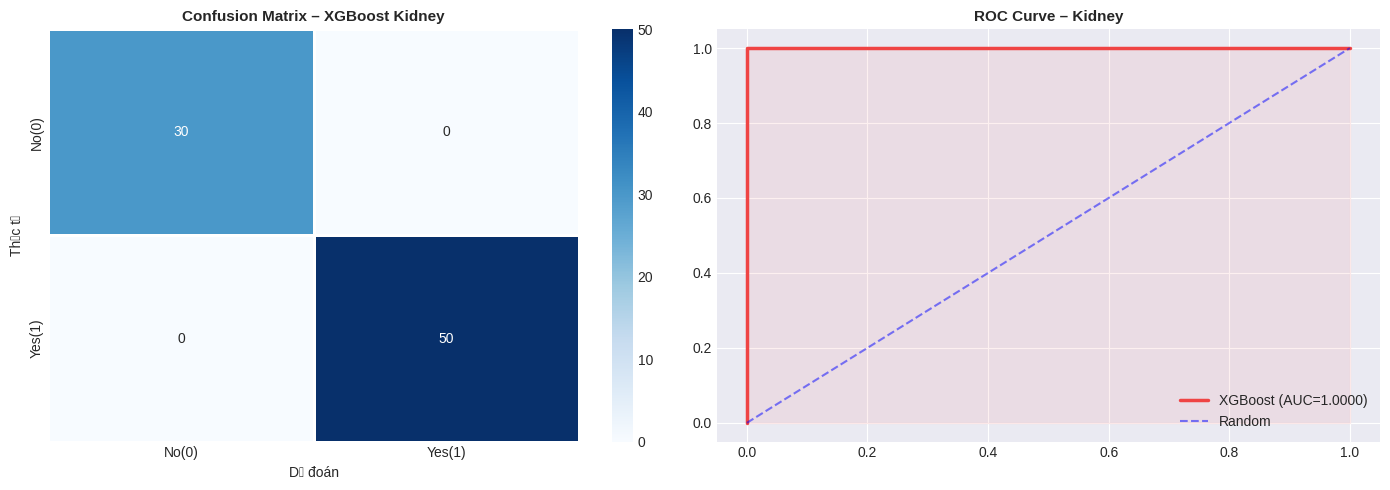

In [7]:
!pip install optuna -q
import optuna
from sklearn.calibration import CalibratedClassifierCV

print("🚀 HUẤN LUYỆN XGBOOST VỚI OPTUNA (thay thế GridSearchCV)")
print("="*70)

# Optuna objective (optimize CV AUC)
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'use_label_encoder': False, 'eval_metric': 'logloss', 'random_state': 42,
        'tree_method': 'hist', 'device': 'cuda'
    }
    cv_str = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    model = xgb.XGBClassifier(**params)
    scores = cross_validate(model, X_train_d, y_train_d, cv=cv_str, scoring='roc_auc', n_jobs=1)
    return scores['test_score'].mean()

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')
print("⏳ Optuna đang quét 30 trials (kidney nhỏ, keep small)...")
study.optimize(objective, n_trials=30)
print(f"✅ Best AUC: {study.best_value:.4f} | Best params: {study.best_params}")

# Train final model using best params
best_params = study.best_params
best_params.update({'use_label_encoder': False, 'eval_metric': 'logloss', 'random_state': 42, 'tree_method': 'hist', 'device': 'cuda'})
best_xgb = xgb.XGBClassifier(**best_params)
best_xgb.fit(X_train_d, y_train_d)
joblib.dump(best_xgb, f'{DIR_MODELS}/kidney_xgboost.pkl')
print(f"💾 Lưu: kidney_xgboost.pkl")

# Evaluate
y_pred_xgb = best_xgb.predict(X_test_d)
y_prob_xgb = best_xgb.predict_proba(X_test_d)[:, 1]
acc_xgb  = accuracy_score(y_test_d, y_pred_xgb)
prec_xgb = precision_score(y_test_d, y_pred_xgb, zero_division=0)
rec_xgb  = recall_score(y_test_d, y_pred_xgb, zero_division=0)
f1_xgb   = f1_score(y_test_d, y_pred_xgb, zero_division=0)
auc_xgb = roc_auc_score(y_test_d, y_prob_xgb) if len(np.unique(y_test_d)) > 1 else 0.0

print("\n📊 ĐÁNH GIÁ XGBOOST – KIDNEY DISEASE")
print(f"  Accuracy  : {acc_xgb:.4f} | Precision : {prec_xgb:.4f} | Recall: {rec_xgb:.4f} | F1: {f1_xgb:.4f} | AUC: {auc_xgb:.4f}")

# Plot Confusion Matrix & ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test_d, y_pred_xgb)
try:
    tn,fp,fn,tp = cm.ravel()
except:
    tn=fp=fn=tp=0
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=['No(0)','Yes(1)'], yticklabels=['No(0)','Yes(1)'], linewidths=1, linecolor='white')
axes[0].set_title('Confusion Matrix – XGBoost Kidney',fontsize=11,weight='bold')
axes[0].set_ylabel('Thực tế'); axes[0].set_xlabel('Dự đoán')

if len(np.unique(y_test_d)) > 1:
    fpr,tpr,_ = roc_curve(y_test_d, y_prob_xgb)
    axes[1].plot(fpr,tpr,color='#ef4444',lw=2.5,label=f'XGBoost (AUC={auc_xgb:.4f})')
    axes[1].plot([0,1],[0,1],'b--',lw=1.5,alpha=0.5,label='Random')
    axes[1].fill_between(fpr,tpr,alpha=0.08,color='#ef4444')
    axes[1].legend(loc='lower right')
axes[1].set_title('ROC Curve – Kidney',fontsize=11,weight='bold')
plt.tight_layout()
plt.savefig(f'{DIR_RESULTS}/K04_xgboost_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## Threshold Tuning & So sánh Random Forest

🚀 TÌM NGƯỠNG TỐI ƯU (THRESHOLD F2)
✅ Ngưỡng F2 tối ưu: 0.5426 → 💾 Lưu: kidney_thresholds.pkl

🚀 HUẤN LUYỆN RANDOM FOREST (Baseline)

🏆 XGBoost vs RF – KIDNEY


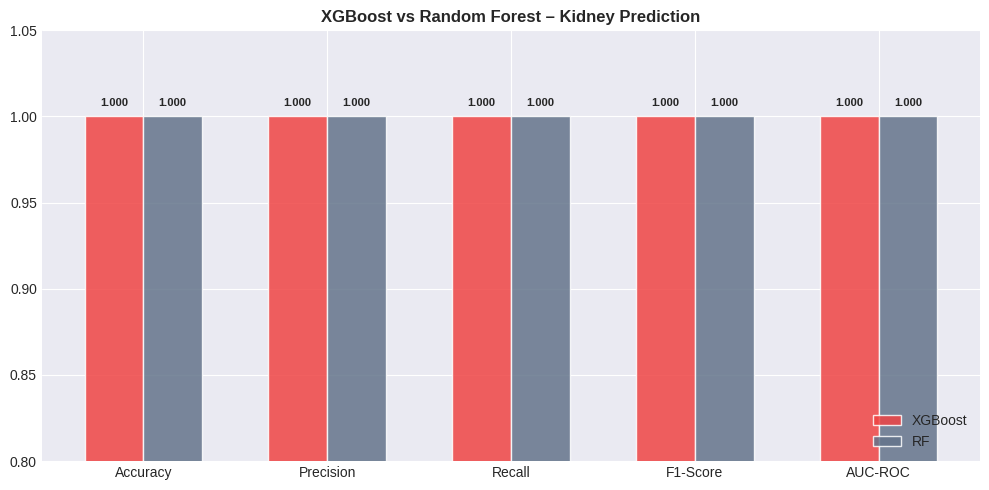


📊 3-FOLD CV CỦA XGBOOST:
  Accuracy    : 0.9825 ± 0.0036
  Recall      : 0.9799 ± 0.0142
  AUC-ROC     : 0.9992 ± 0.0008


In [8]:
print("🚀 TÌM NGƯỠNG TỐI ƯU (THRESHOLD F2)")
precisions, recalls, thresholds = precision_recall_curve(y_test_d, y_prob_xgb)
f2_scores = (5*(precisions[:-1]*recalls[:-1]))/(4*precisions[:-1]+recalls[:-1]+1e-8)
best_t_f2 = thresholds[np.argmax(f2_scores)]
joblib.dump({'default':0.5, 'f2_medical':float(best_t_f2)}, f'{DIR_MODELS}/kidney_thresholds.pkl')
print(f"✅ Ngưỡng F2 tối ưu: {best_t_f2:.4f} → 💾 Lưu: kidney_thresholds.pkl")

print("\n🚀 HUẤN LUYỆN RANDOM FOREST (Baseline)")
rf_model = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, n_jobs=-1, class_weight='balanced')
rf_model.fit(X_train_d, y_train_d)
joblib.dump(rf_model, f'{DIR_MODELS}/kidney_randomforest.pkl')

y_pred_rf = rf_model.predict(X_test_d); y_prob_rf = rf_model.predict_proba(X_test_d)[:,1]
acc_rf, prec_rf, rec_rf = accuracy_score(y_test_d,y_pred_rf), precision_score(y_test_d,y_pred_rf, zero_division=0), recall_score(y_test_d,y_pred_rf, zero_division=0)
f1_rf, auc_rf = f1_score(y_test_d,y_pred_rf, zero_division=0), roc_auc_score(y_test_d,y_prob_rf)

print("\n🏆 XGBoost vs RF – KIDNEY")
metrics_n = ['Accuracy','Precision','Recall','F1-Score','AUC-ROC']
xgb_s = [acc_xgb, prec_xgb, rec_xgb, f1_xgb, auc_xgb]
rf_s  = [acc_rf, prec_rf, rec_rf, f1_rf, auc_rf]

# Bar Chart So sánh
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metrics_n)); w = 0.32
b1 = ax.bar(x - w/2, xgb_s, w, label='XGBoost', color='#ef4444', alpha=0.85, edgecolor='white')
b2 = ax.bar(x + w/2, rf_s,  w, label='RF',      color='#64748b', alpha=0.85, edgecolor='white')
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, weight='bold')
ax.set_xticks(x); ax.set_xticklabels(metrics_n); ax.set_ylim([0.80, 1.05])
ax.set_title('XGBoost vs Random Forest – Kidney Prediction', fontsize=12, weight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'{DIR_RESULTS}/K06_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Cross-validation
from sklearn.model_selection import StratifiedKFold

cv_str = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_res = cross_validate(best_xgb, X_train_d, y_train_d, cv=cv_str, scoring={'accuracy':'accuracy','recall':'recall','roc_auc':'roc_auc'}, n_jobs=1)
print("\n📊 3-FOLD CV CỦA XGBOOST:")
for m,k in [('Accuracy','test_accuracy'),('Recall','test_recall'),('AUC-ROC','test_roc_auc')]:
    print(f"  {m:12s}: {cv_res[k].mean():.4f} ± {cv_res[k].std():.4f}")

## SHAP Explainer & Waterfall

---
## 🔍 PHẦN 4: EXPLAINABLE AI VỚI SHAP
---

⏳ SHAP TreeExplainer...


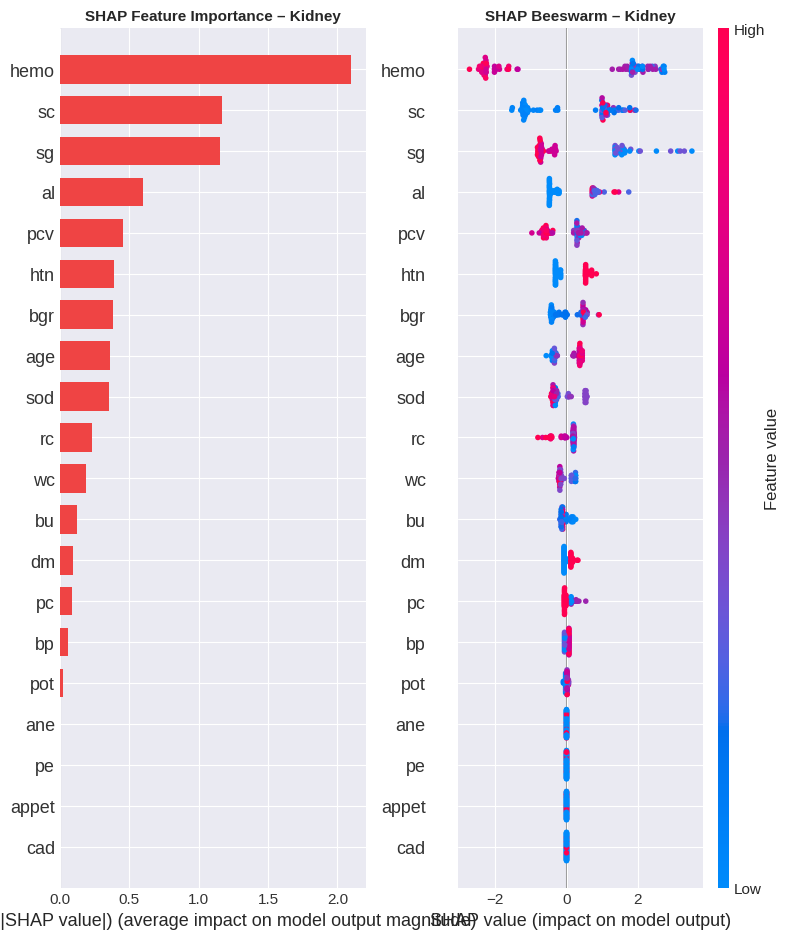

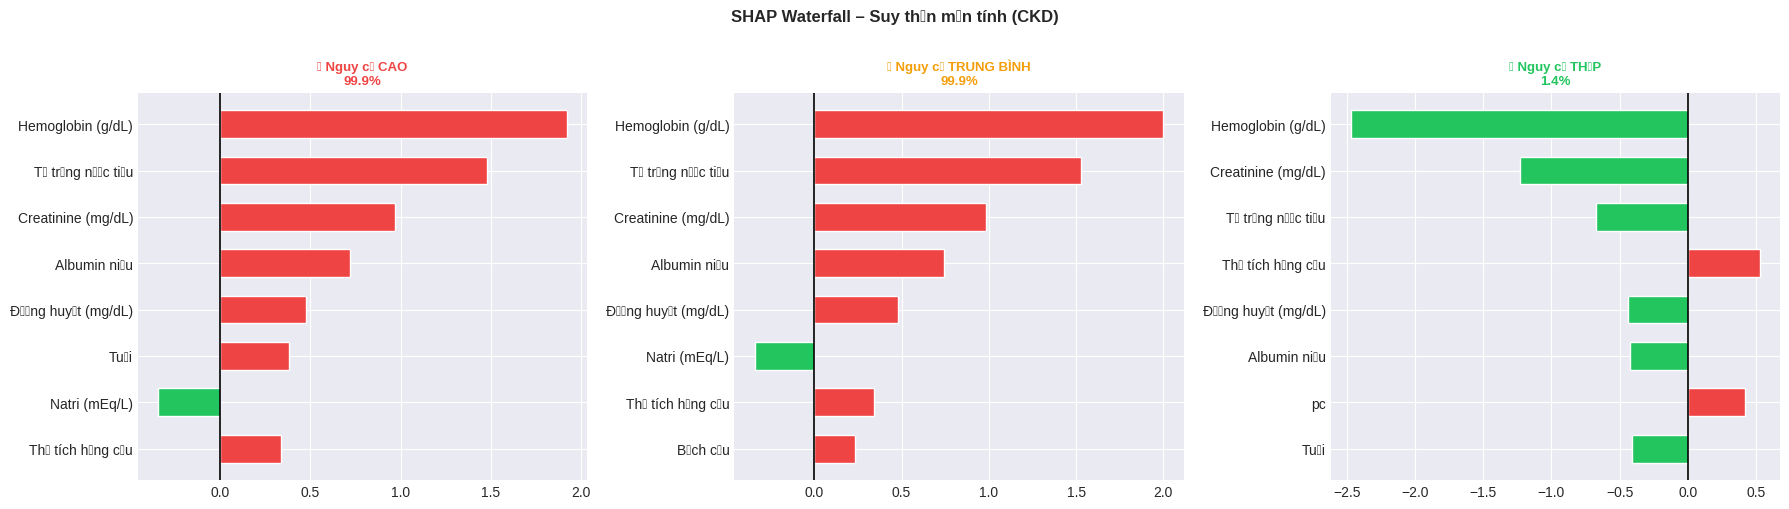

In [9]:
print("---")
print("## 🔍 PHẦN 4: EXPLAINABLE AI VỚI SHAP")
print("---\n")

# Khởi tạo SHAP
print(f"⏳ SHAP TreeExplainer...")
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_d)
joblib.dump(explainer, f'{DIR_MODELS}/kidney_shap_explainer.pkl')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
plt.sca(axes[0])
shap.summary_plot(shap_values, X_test_d, feature_names=FEATURE_NAMES, plot_type='bar', show=False, color='#ef4444')
axes[0].set_title('SHAP Feature Importance – Kidney',fontsize=11,weight='bold')
plt.sca(axes[1])
shap.summary_plot(shap_values, X_test_d, feature_names=FEATURE_NAMES, show=False)
axes[1].set_title('SHAP Beeswarm – Kidney',fontsize=11,weight='bold')
plt.tight_layout()
plt.savefig(f'{DIR_RESULTS}/K05_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# Mô phỏng 3 Ca Lâm sàng (Waterfall)
# ==========================================
FEATURE_LABELS_K = {'age': 'Tuổi', 'bp': 'Huyết áp (mmHg)', 'sg': 'Tỷ trọng nước tiểu', 'al': 'Albumin niệu', 'su': 'Đường niệu', 'bgr': 'Đường huyết (mg/dL)', 'bu': 'Ure máu (mg/dL)', 'sc': 'Creatinine (mg/dL)', 'sod': 'Natri (mEq/L)', 'pot': 'Kali (mEq/L)', 'hemo': 'Hemoglobin (g/dL)', 'pcv': 'Thể tích hồng cầu', 'wc': 'Bạch cầu', 'htn': 'Tăng huyết áp', 'dm': 'Tiểu đường', 'pe': 'Phù nề', 'ane': 'Thiếu máu'}

def get_shap_explanation_kidney(input_dict):
    raw = [float(input_dict.get(f, 0)) for f in FEATURE_NAMES]
    X_sc = scaler.transform(np.array(raw).reshape(1,-1))
    sv = explainer.shap_values(X_sc)[0]
    prob = float(best_xgb.predict_proba(X_sc)[0][1])

    feat_list = [{'name':f,'value':round(raw[i],2), 'shap_value':round(float(sv[i]),4), 'label_vn':FEATURE_LABELS_K.get(f,f)} for i,f in enumerate(FEATURE_NAMES)]
    feat_list.sort(key=lambda x: abs(x['shap_value']), reverse=True)
    return {'prediction_prob':prob, 'features':feat_list}

CASES_KIDNEY = {
    '🔴 Nguy cơ CAO': {'age':65, 'bp':140, 'sg':1.010, 'al':4, 'bgr':250, 'sc':5.5, 'hemo':9.0, 'htn':1, 'dm':1},
    '🟡 Nguy cơ TRUNG BÌNH': {'age':50, 'bp':130, 'sg':1.015, 'al':1, 'bgr':140, 'sc':1.8, 'hemo':12.0, 'htn':1, 'dm':0},
    '🟢 Nguy cơ THẤP': {'age':30, 'bp':110, 'sg':1.020, 'al':0, 'bgr':90, 'sc':0.9, 'hemo':15.0, 'htn':0, 'dm':0}
}

fig, axes = plt.subplots(1,3,figsize=(18,5))
colors_r = {'🔴 Nguy cơ CAO':'#ef4444','🟡 Nguy cơ TRUNG BÌNH':'#f59e0b','🟢 Nguy cơ THẤP':'#22c55e'}
for ax,(cname, cdata) in zip(axes, CASES_KIDNEY.items()):
    r = get_shap_explanation_kidney(cdata)
    feats = r['features'][:8]
    names = [f['label_vn'][:22] for f in feats]
    svs   = [f['shap_value'] for f in feats]
    bc    = ['#ef4444' if v>0 else '#22c55e' for v in svs]
    ax.barh(names[::-1], svs[::-1], color=bc[::-1], edgecolor='white', height=0.6)
    ax.axvline(x=0, color='black', lw=1.2)
    ax.set_title(f"{cname}\n{r['prediction_prob']*100:.1f}%", fontsize=9.5, weight='bold', color=colors_r[cname])
plt.suptitle('SHAP Waterfall – Suy thận mạn tính (CKD)',fontsize=12,weight='bold',y=1.01)
plt.tight_layout()
plt.savefig(f'{DIR_RESULTS}/K07_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()